# 实验-TX-功耗-距离


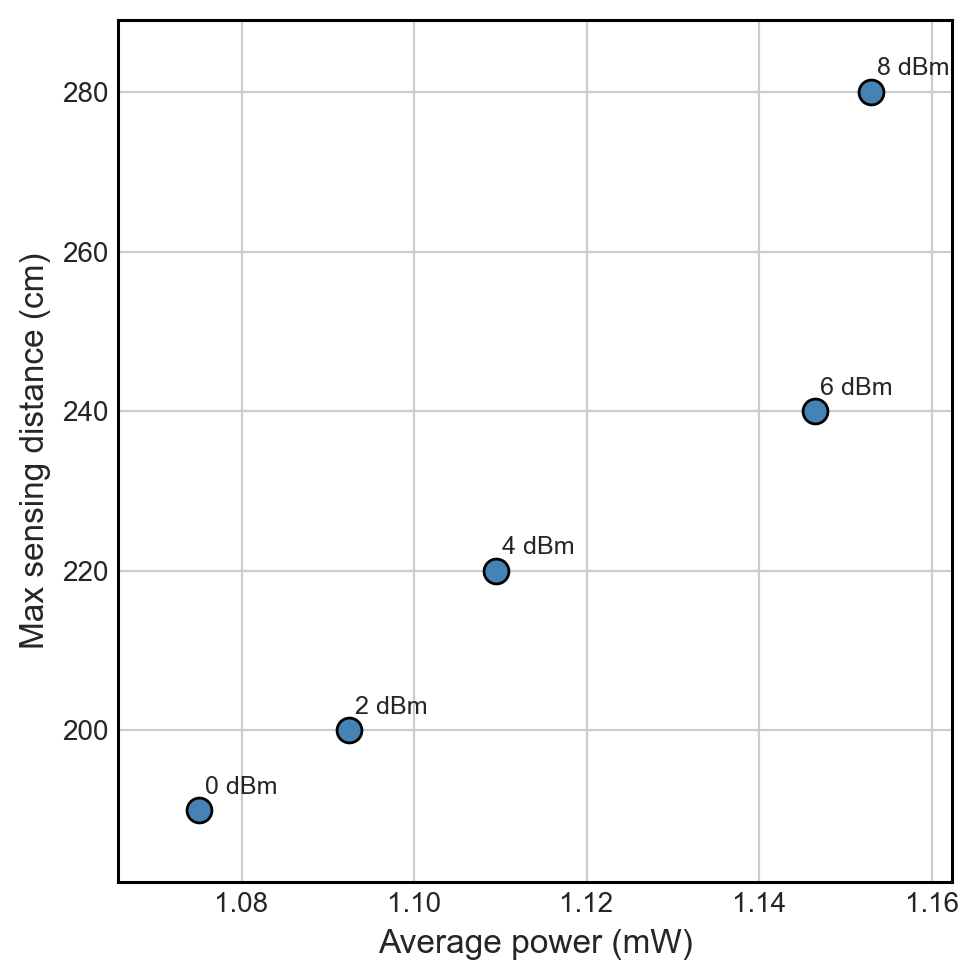

In [7]:
import matplotlib.pyplot as plt
from pathlib import Path
out_dir = Path("./outputs")
out_dir.mkdir(parents=True, exist_ok=True)
# ---- CS data ----
tx_dbm = [0, 2, 4, 6, 8]
max_dist_cm = [190, 200, 220, 240, 280]
avg_power_mw = [1.075086, 1.092474, 1.109556, 1.146474, 1.152972]  # 全CS时段平均电流 (mA)

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(5,5), dpi=200)

# Scatter: x=current, y=distance (no colorbar/legend)
ax.scatter(avg_power_mw, max_dist_cm, s=80, color="steelblue",edgecolors="black",)

# Annotate each point with Tx power
for x, y, p in zip(avg_power_mw, max_dist_cm, tx_dbm):
    ax.annotate(f"{p} dBm", (x, y), textcoords="offset points", xytext=(2, 6), fontsize=9)

# Black box frame (all spines on + black)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.1)

# ax.set_xlabel("Average current during CS (mA)",fontsize=12)
ax.set_xlabel("Average power (mW)",fontsize=12)
ax.set_ylabel("Max sensing distance (cm)",fontsize=12)
# ax.set_title("Sensing distance vs. average current during CS",fontsize=13, fontweight='bold')

# Optional: make the "upper-left is better" message explicit with axis limits
x_pad = (max(avg_power_mw) - min(avg_power_mw)) * 0.12 or 0.01
y_pad = (max(max_dist_cm) - min(max_dist_cm)) * 0.10 or 5
ax.set_xlim(min(avg_power_mw) - x_pad, max(avg_power_mw) + x_pad)
ax.set_ylim(min(max_dist_cm) - y_pad, max(max_dist_cm) + y_pad)

fig.tight_layout()
# 存储图片

output_path_png = out_dir / f"cs_power_vs_distance.png"
output_path_svg = out_dir / f"cs_power_vs_distance.svg"
output_path_pdf = out_dir / f"cs_power_vs_distance.pdf"
# plt.savefig(output_path_png, dpi=200)  
# plt.savefig(output_path_svg, dpi=200)  
plt.savefig(output_path_pdf, dpi=200) 


plt.show()

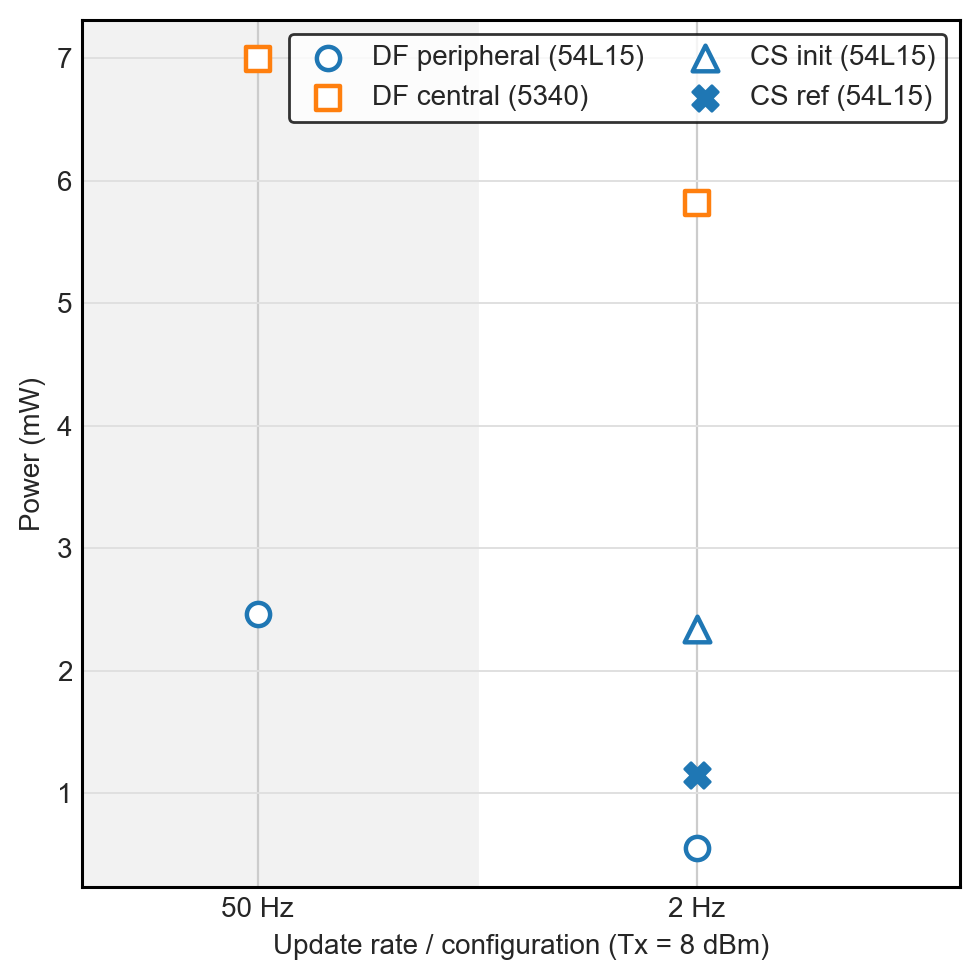

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# -------- Inputs (confirmed) --------
V_54L15 = 1.8
V_5340  = 3.0

conds = ["50 Hz", "2 Hz"]  # 50 Hz: evt=10ms, CTE=20ms; 2 Hz: evt=250ms, CTE=500ms
x = np.arange(len(conds))

# DF (Tx = 8 dBm)
df_periph_I_54 = np.array([1.37, 0.31])  # 54L15 @1.8V  (DF peripheral)
df_central_I_53 = np.array([2.33, 1.94]) # 5340  @3.0V  (DF central)

# CS references at 8 dBm (device: 54L15)
cs_ref_I_54  = 0.63754  # mA @1.8V
cs_init_I_54 = 1.3      # mA @1.8V

# Convert to power in mW: P(mW) = V(V) * I(mA)
df_periph_P = V_54L15 * df_periph_I_54
df_central_P = V_5340  * df_central_I_53
cs_ref_P  = V_54L15 * cs_ref_I_54
cs_init_P = V_54L15 * cs_init_I_54

# -------- Plot styling (paper-like) --------
plt.rcParams.update({
    "font.size": 10,
    "axes.linewidth": 1.1,
})

c_54 = "tab:blue"    # 54L15
c_53 = "tab:orange"  # 5340

fig, ax = plt.subplots(figsize=(5, 5), dpi=200)

# Highlight 50 Hz column subtly (optional, can remove if you want cleaner)
ax.axvspan(-0.5, 0.5, color="0.95", zorder=0)

# DF points (condition-dependent)
ax.scatter(
    x, df_periph_P,
    s=70, marker="o", facecolors="white", edgecolors=c_54, linewidths=1.6,
    label="DF peripheral (54L15)", zorder=3
)
ax.scatter(
    x, df_central_P,
    s=70, marker="s", facecolors="white", edgecolors=c_53, linewidths=1.6,
    label="DF central (5340)", zorder=3
)

# CS init/ref as horizontal references + explicit markers
# ax.axhline(cs_init_P, color=c_54, linestyle="--", linewidth=1.2, zorder=1)
# ax.axhline(cs_ref_P,  color=c_54, linestyle=":",  linewidth=1.6, zorder=1)

# Put markers at the right side so legend shows marker styles clearly
x_ref = x[-1] + 0
# x_ref = x
ax.scatter(
    [x_ref], [cs_init_P],
    s=85, marker="^", facecolors="white", edgecolors=c_54, linewidths=1.6,
    label="CS init (54L15)", zorder=4
)
ax.scatter(
    [x_ref], [cs_ref_P],
    s=85, marker="X", color=c_54,
    label="CS ref (54L15)", zorder=4
)

# Axes
ax.set_xticks(x)
ax.set_xticklabels(conds)
ax.set_xlabel("Update rate / configuration (Tx = 8 dBm)")
ax.set_ylabel("Power (mW)")
ax.set_xlim(-0.4, x[-1] + 0.60)

# ax.set_title("Power Comparison at 8 dBm",fontsize=13,fontweight='bold')

# Grid + black frame
ax.grid(True, axis="y", color="0.88", linewidth=0.7)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.1)

# Legend: compact, 2 columns
ax.legend(frameon=True, ncol=2, loc="upper right", columnspacing=1.2, handletextpad=0.6,edgecolor='black')

fig.tight_layout()

# 存储图片
output_path_png = out_dir / f"Power_Comparison_at_8dBm.png"
output_path_svg = out_dir / f"Power_Comparison_at_8dBm.svg"
output_path_pdf = out_dir / f"Power_Comparison_at_8dBm.pdf"
# plt.savefig(output_path_png, dpi=200)  
# plt.savefig(output_path_svg, dpi=200)  
plt.savefig(output_path_pdf, dpi=200) 

plt.show()

# Optional export
# fig.savefig("power_comparison_tx8dbm.pdf", bbox_inches="tight")